In [12]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import skfuzzy as fuzz
plt.rcParams['figure.figsize'] = [10, 5]
plt.rcParams['font.size'] = 12
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3


## **Building a Mamdani Inference from Scratch**
We will implement the complete Mamdani inference pipeline step by step using the **project staffing** example from the lectures.

**Problem:** A project's **risk** depends on its **funding** level and **staffing** level.

**Linguistic variables:**
**Funding (0–100%):** Inadequate, Marginal, Adequate
**Staffing (0–20 people):** Small, Large
**Risk (0–100%):** Low, Normal, High

**Rules:**
1. IF funding IS adequate OR staffing IS small THEN risk IS low
2. IF funding IS marginal AND staffing IS large THEN risk IS normal
3. IF funding IS inadequate THEN risk IS high

**Crisp inputs (from lectures):** funding = 35%, staffing = 60%.

The slides use staffing as a percentage (0–100%), but let's adopt staffing as headcount (1–20) here.

### Step 1 Defining Membership Functions

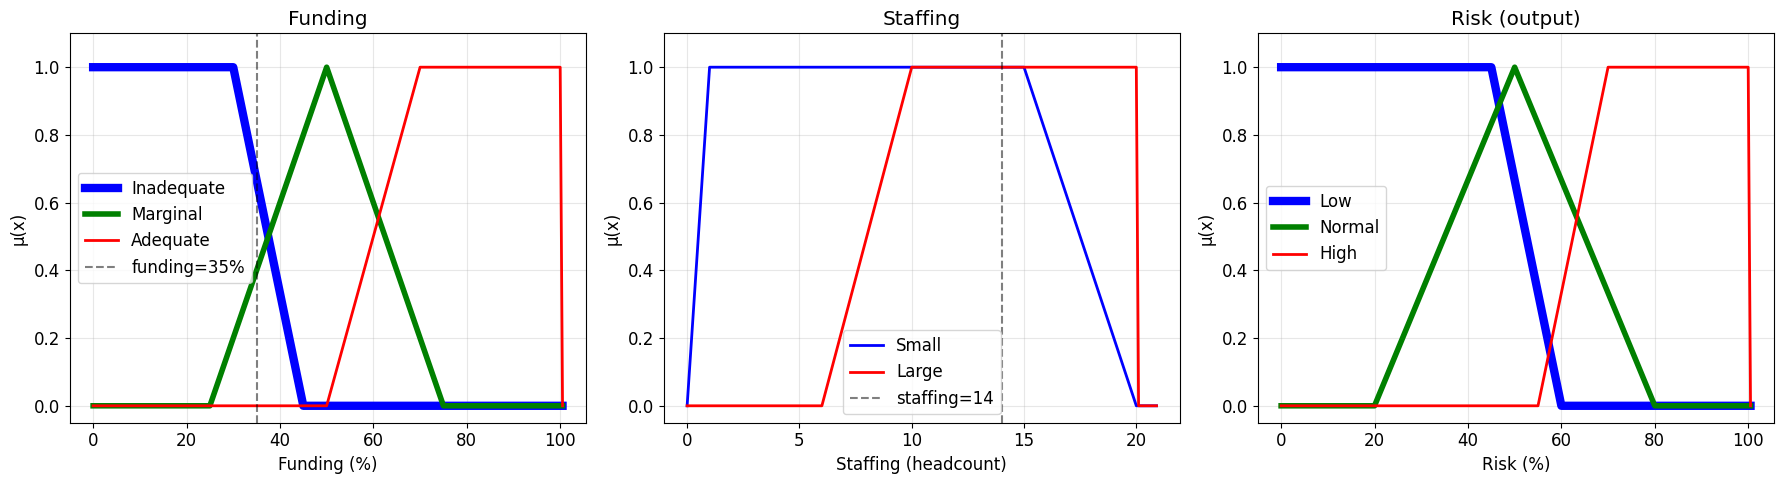

In [13]:
# Universes of discourse
x_fund = np.arange(0, 101, 0.5)
x_staff = np.arange(0, 21, 0.1)
x_risk = np.arange(0, 101, 0.5)

# --- Funding MFs ---
# Inadequate: (0,1)→(30,1)→(45,0) — trapezoidal left-shoulder
fund_inadequate = fuzz.trapmf(x_fund, [0, 0, 30, 45])
# Marginal: triangle (25, 50, 75)
# TODO: create the "marginal" fuzzy set here
# Tip: use skfuzzy's "trimf" function
fund_marginal = fuzz.trimf(x_fund, [25, 50, 75])

# Adequate: (50,0)→(70,1)→(100,1) — trapezoidal right-shoulder
# TODO: create the "adequate" fuzzy set here
fund_adequate = fuzz.trapmf(x_fund, [50, 70, 100, 100])

# --- Staffing MFs ---
# Small: (1,1)→(15,0) left-shoulder trapezoid
# TODO: create the "small" fuzzy set here
staff_small = fuzz.trapmf(x_staff, [0, 1, 15, 20])

# Large: (6,0)→(20,1) right-shoulder trapezoid
# TODO: create the "large" fuzzy set here
staff_large = fuzz.trapmf(x_staff, [6, 10, 20, 20])

# --- Risk MFs ---
# Low: (0,1)→(45,0) left-shoulder trapezoid
# TODO: create the "low" fuzzy set here
risk_low = fuzz.trapmf(x_risk, [0, 0, 45, 60])

# Normal: triangle (20, 50, 80)
# TODO: create the "normal" fuzzy set here
risk_normal = fuzz.trimf(x_risk, [20, 50, 80])

# High: (55,0)→(100,1) right-shoulder trapezoid
# TODO: create the "high" fuzzy set here
risk_high = fuzz.trapmf(x_risk, [55, 70, 100, 100])

# --- Plot ---
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))
ax1.plot(x_fund, fund_inadequate, 'b-', lw=6, label='Inadequate')
ax1.plot(x_fund, fund_marginal, 'g-', lw=4, label='Marginal')
ax1.plot(x_fund, fund_adequate, 'r-', lw=2, label='Adequate')
ax1.axvline(x=35, color='k', ls='--', alpha=0.5, label='funding=35%')
ax1.set_title('Funding')
ax1.set_xlabel('Funding (%)')
ax1.set_ylabel('μ(x)')
ax1.legend()

ax2.plot(x_staff, staff_small, 'b-', lw=2, label='Small')
ax2.plot(x_staff, staff_large, 'r-', lw=2, label='Large')
ax2.axvline(x=14, color='k', ls='--', alpha=0.5, label='staffing=14')
ax2.set_title('Staffing')
ax2.set_xlabel('Staffing (headcount)')
ax2.set_ylabel('μ(x)')
ax2.legend()

ax3.plot(x_risk, risk_low, 'b-', lw=6, label='Low')
ax3.plot(x_risk, risk_normal, 'g-', lw=4, label='Normal')
ax3.plot(x_risk, risk_high, 'r-', lw=2, label='High')
ax3.set_title('Risk (output)')
ax3.set_xlabel('Risk (%)')
ax3.set_ylabel('μ(x)')
ax3.legend()

for ax in [ax1, ax2, ax3]:
    ax.set_ylim(-0.05, 1.1)
plt.tight_layout()
plt.show()

### Step 2 Fuzzification

In [5]:
# Crisp inputs
funding_val = 35
staffing_val = 14

# Fuzzify funding
# Calculate the degree of membership (DoM) for "inadequate"
mu_inadequate = fuzz.interp_membership(x_fund, fund_inadequate, funding_val)

# TODO: Calculate DoM for "marginal" here
mu_marginal = fuzz.interp_membership(x_fund, fund_marginal, funding_val)

# TODO: Calculate DoM for "adequate" here
mu_adequate = fuzz.interp_membership(x_fund, fund_adequate, funding_val)

# Fuzzify staffing

# TODO: Calculate DoM for "small" here
mu_small = fuzz.interp_membership(x_staff, staff_small, staffing_val)

# TODO: Calculate DoM for "large" here
mu_large = fuzz.interp_membership(x_staff, staff_large, staffing_val)

print(f"Fuzzification: funding = {funding_val}%, staffing = {staffing_val}")
print(f"{'─' * 45}")
print(f" μ_inadequate({funding_val}) = {mu_inadequate:.4f}")
print(f" μ_marginal({funding_val}) = {mu_marginal:.4f}")
print(f" μ_adequate({funding_val}) = {mu_adequate:.4f}")
print()
print(f" μ_small({staffing_val}) = {mu_small:.4f}")
print(f" μ_large({staffing_val}) = {mu_large:.4f}")

Fuzzification: funding = 35%, staffing = 14
─────────────────────────────────────────────
 μ_inadequate(35) = 0.6667
 μ_marginal(35) = 0.4000
 μ_adequate(35) = 0.0000

 μ_small(14) = 1.0000
 μ_large(14) = 1.0000


Rule evaluation:
 Rule 1: max(adequate=0.000, small=1.000) = 1.000 → clip 'low'
 Rule 2: min(marginal=0.400, large=1.000) = 0.400 → clip 'normal'
 Rule 3: inadequate = 0.667 → clip 'high'


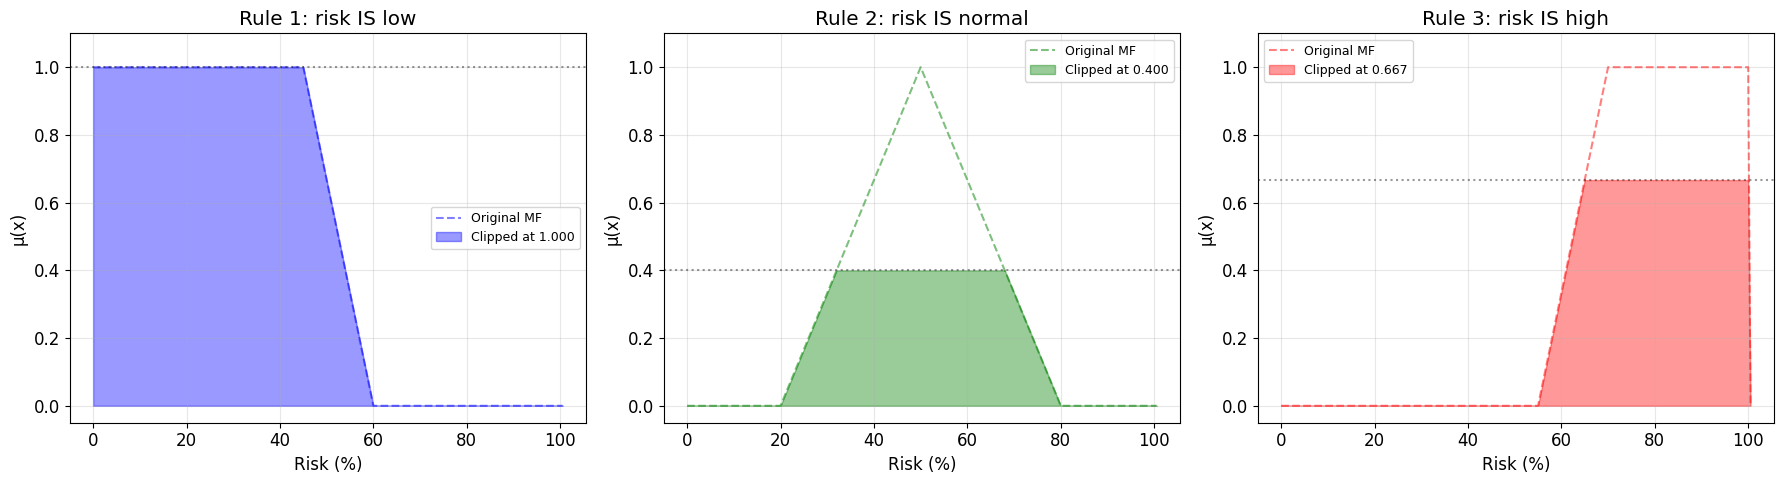

In [14]:
# Rule 1: IF funding IS adequate OR (max) staffing IS small THEN risk IS low
rule1_strength = max(mu_adequate, mu_small)
rule1_output = np.minimum(rule1_strength, risk_low) # Clip (min-implication)

# Rule 2: IF funding IS marginal AND (min) staffing IS large THEN risk IS normal
# TODO: Code Rule 2 here
rule2_strength = min(mu_marginal, mu_large)
rule2_output = np.minimum(rule2_strength, risk_normal) # Clip (min-implication)

# Rule 3: IF funding IS inadequate THEN risk IS high
rule3_strength = mu_inadequate
rule3_output = np.minimum(rule3_strength, risk_high) # Clip

print("Rule evaluation:")
print(f" Rule 1: max(adequate={mu_adequate:.3f}, small={mu_small:.3f}) " \
    f"= {rule1_strength:.3f} → clip 'low'")
print(f" Rule 2: min(marginal={mu_marginal:.3f}, large={mu_large:.3f}) " \
    f"= {rule2_strength:.3f} → clip 'normal'")
print(f" Rule 3: inadequate = {rule3_strength:.3f} → clip 'high'")

# Plot clipped consequents
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
titles = ['Rule 1: risk IS low', 'Rule 2: risk IS normal', 'Rule 3: risk IS high']
originals = [risk_low, risk_normal, risk_high]
clipped = [rule1_output, rule2_output, rule3_output]
strengths = [rule1_strength, rule2_strength, rule3_strength]
colors = ['blue', 'green', 'red']

for ax, title, orig, clip, strength, color in zip(axes, titles, originals, clipped, strengths, colors):
    ax.plot(x_risk, orig, color=color, ls='--', lw=1.5, alpha=0.5, label='Original MF')
    ax.fill_between(x_risk, clip, alpha=0.4, color=color, label=f'Clipped at {strength:.3f}')
    ax.axhline(y=strength, color='k', ls=':', alpha=0.4)
    ax.set_title(title)
    ax.set_xlabel('Risk (%)')
    ax.set_ylabel('μ(x)')
    ax.set_ylim(-0.05, 1.1)
    ax.legend(fontsize=9)
    
plt.tight_layout()
plt.show()


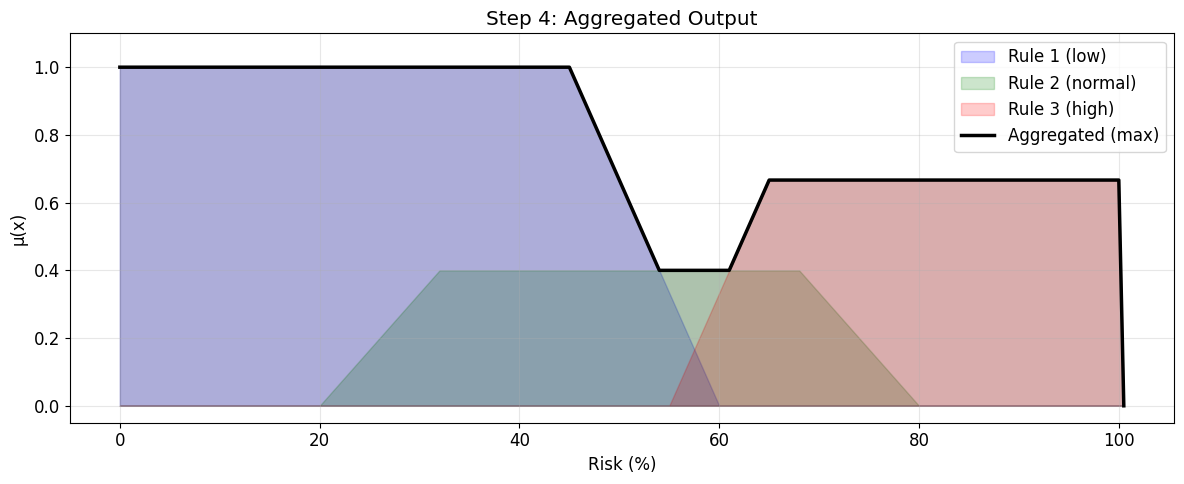

In [15]:
# Aggregate using max
# TODO: Calculate the "aggregated" result by using numpy's "maximum" function
# on the Rules 1, 2, and 3 outputs
aggregated = np.maximum.reduce([rule1_output, rule2_output, rule3_output])

# Plot
fig, ax = plt.subplots(figsize=(12, 5))
ax.fill_between(x_risk, rule1_output, alpha=0.2, color='blue', label='Rule 1 (low)')
ax.fill_between(x_risk, rule2_output, alpha=0.2, color='green', label='Rule 2 (normal)')
ax.fill_between(x_risk, rule3_output, alpha=0.2, color='red', label='Rule 3 (high)')
ax.plot(x_risk, aggregated, 'k-', lw=2.5, label='Aggregated (max)')
ax.fill_between(x_risk, aggregated, alpha=0.15, color='black')
ax.set_title('Step 4: Aggregated Output')
ax.set_xlabel('Risk (%)')
ax.set_ylabel('μ(x)')
ax.set_ylim(-0.05, 1.1)
ax.legend()
plt.tight_layout()
plt.show()


### Step 5 - Defuzzification

Defuzzification results (funding=35%, staffing=14):
 COG (Centre of Gravity): 44.48%
 MOM (Mean of Maxima): 22.50%
 SOM (Smallest of Maxima): 0.00%
 LOM (Largest of Maxima): 45.00%


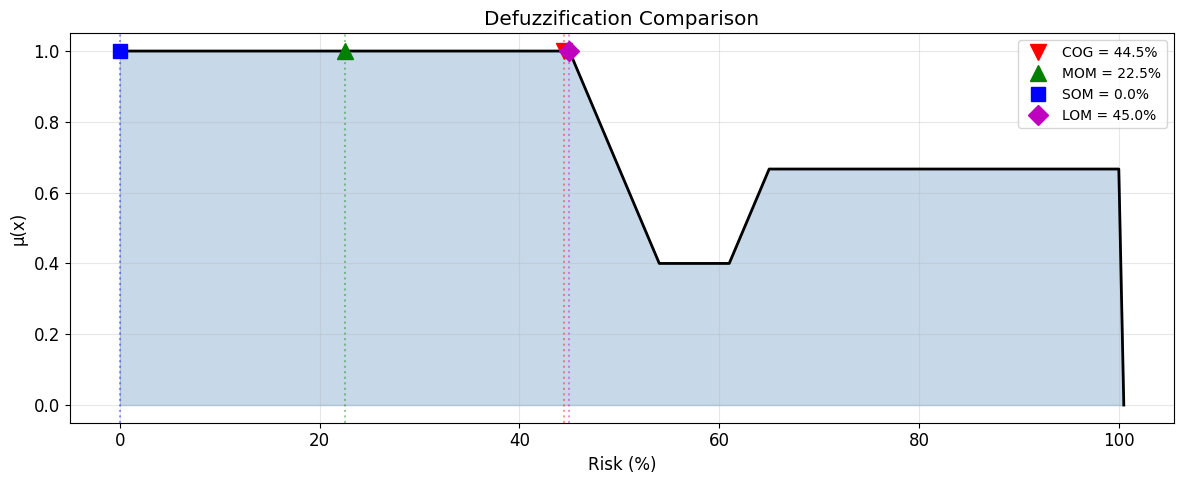

In [16]:
def defuzzify_cog(x, mf):
    """Centre of Gravity (centroid) defuzzification."""
    if np.sum(mf) == 0:
        return 0
    # TODO: Compute and return the COG result using the
    # numpy's "sum" function twice here
    # Tip: See the COG equation in the MD cell above,
    # where "z" there is the "x" attribute here
    return np.sum(x * mf) / np.sum(mf)

def defuzzify_mom(x, mf):
    """Mean of Maxima defuzzification."""
    max_val = np.max(mf)
    if max_val == 0:
        return 0
    max_indices = np.where(np.isclose(mf, max_val, atol=1e-6))[0]
    return np.mean(x[max_indices])

def defuzzify_som(x, mf):
    """Smallest of Maxima defuzzification."""
    max_val = np.max(mf)
    if max_val == 0:
        return 0
    max_indices = np.where(np.isclose(mf, max_val, atol=1e-6))[0]
    return x[max_indices[0]]

def defuzzify_lom(x, mf):
    """Largest of Maxima defuzzification."""
    max_val = np.max(mf)
    if max_val == 0:
        return 0
    max_indices = np.where(np.isclose(mf, max_val, atol=1e-6))[0]
    return x[max_indices[-1]]

# Compute all four
# Compute COG
cog = defuzzify_cog(x_risk, aggregated)
# TODO: Compute MOM
mom = defuzzify_mom(x_risk, aggregated)
# TODO: Compute SOM
som = defuzzify_som(x_risk, aggregated)
# TODO: Compute LOM
lom = defuzzify_lom(x_risk, aggregated)

print(f"Defuzzification results (funding={funding_val}%, staffing={staffing_val}):")
print(f" COG (Centre of Gravity): {cog:.2f}%")
print(f" MOM (Mean of Maxima): {mom:.2f}%")
print(f" SOM (Smallest of Maxima): {som:.2f}%")
print(f" LOM (Largest of Maxima): {lom:.2f}%")

# Plot with defuzzification points
fig, ax = plt.subplots(figsize=(12, 5))
ax.fill_between(x_risk, aggregated, alpha=0.3, color='steelblue')
ax.plot(x_risk, aggregated, 'k-', lw=2)

markers = {'COG': (cog, 'rv', 12), 'MOM': (mom, 'g^', 12),
 'SOM': (som, 'bs', 10), 'LOM': (lom, 'mD', 10)}

for name, (val, marker, ms) in markers.items():
    ax.plot(val, fuzz.interp_membership(x_risk, aggregated, val),
    marker, markersize=ms, label=f'{name} = {val:.1f}%')
    ax.axvline(x=val, color=marker[0], ls=':', alpha=0.4)
ax.set_title('Defuzzification Comparison')
ax.set_xlabel('Risk (%)')
ax.set_ylabel('μ(x)')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

## **Part 2 - Fuzzy Inference with pyfuzzylite**
Now we rebuild the same system using the pyfuzzylite library, which supports all three inference methods (Mamdani, Sugeno, Tsukamoto) and all defuzzification methods.

pyfuzzylite is the Python implementation of the FuzzyLite library family (also available in C++ and Java).

Its rule syntax closely matches the natural-language style used in lectures and exams.